# Leak Checks

This notebook is the central place for HFE system leak analysis. It starts with the system $N_2$ pressure-decay leak test and will later absorb the vacuum pressure-rise and reservoir leak checks.

## Notebook roadmap

1. Locate the repository root and raw data directory.
2. Run the system-pressure leak analysis through `orca.leaks`.
3. Display the updated pressure-decay figures for the full system and reservoir tests.
4. Add the vacuum pressure-rise section next.

In [21]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import orca
import orca.leaks as leak_tools

importlib.reload(leak_tools)
importlib.reload(orca)


<module 'orca' from '/home/aamy/Documents/hfe-system/analysis/src/orca/__init__.py'>

In [22]:
NB_PATH = Path.cwd()
REPO_ROOT = NB_PATH
for candidate in [NB_PATH, *NB_PATH.parents]:
    if (candidate / 'data').exists() and (candidate / 'analysis').exists():
        REPO_ROOT = candidate
        break

RAW_DIR = REPO_ROOT / 'data' / 'raw'

print(f'ORCA: {orca.ORCA_MEANING}')
print(f'Repo root: {REPO_ROOT}')


ORCA: Operational Recirculation and Cryogenic Analysis
Repo root: /home/aamy/Documents/hfe-system


## 1. System pressure leak checks

Update the log list below as new system leak runs are taken.

In [23]:
SYSTEM_PRESSURE_LOGS = [
    RAW_DIR / 'log_20260311_114721.csv',
    RAW_DIR / 'log_20260312_172440.csv',
]

system_results = [leak_tools.analyze_system_pressure_log(path) for path in SYSTEM_PRESSURE_LOGS]
system_summary = leak_tools.system_pressure_summary_table(system_results)
display(
    system_summary.round(
        {
            'elapsed_h': 3,
            'fit_asymptote_bar_abs': 4,
            'fit_k_per_h': 5,
            'mean_pressure_bar_abs': 3,
            'leak_mbar_l_s': 4,
            'hfe_loss_l_year': 2,
            'rmse_mbar': 1,
        }
    )
)


,log_file,elapsed_h,fit_asymptote_bar_abs,fit_k_per_h,mean_pressure_bar_abs,leak_mbar_l_s,hfe_loss_l_year,rmse_mbar
0,log_20260311_114721.csv,2.915,1.0117,-0.47035,1.153,0.1274,2.85,8.5
1,log_20260312_172440.csv,17.119,1.0327,-0.47983,1.153,0.1300,2.91,10.0


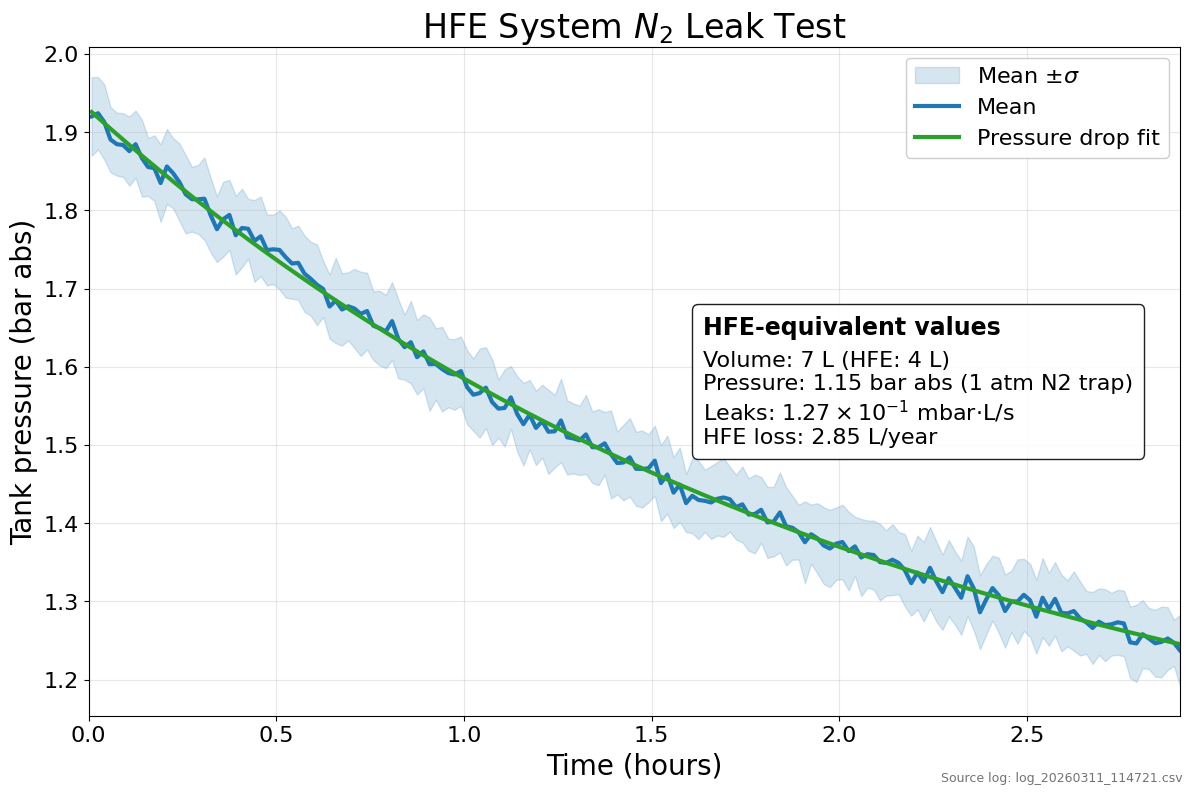

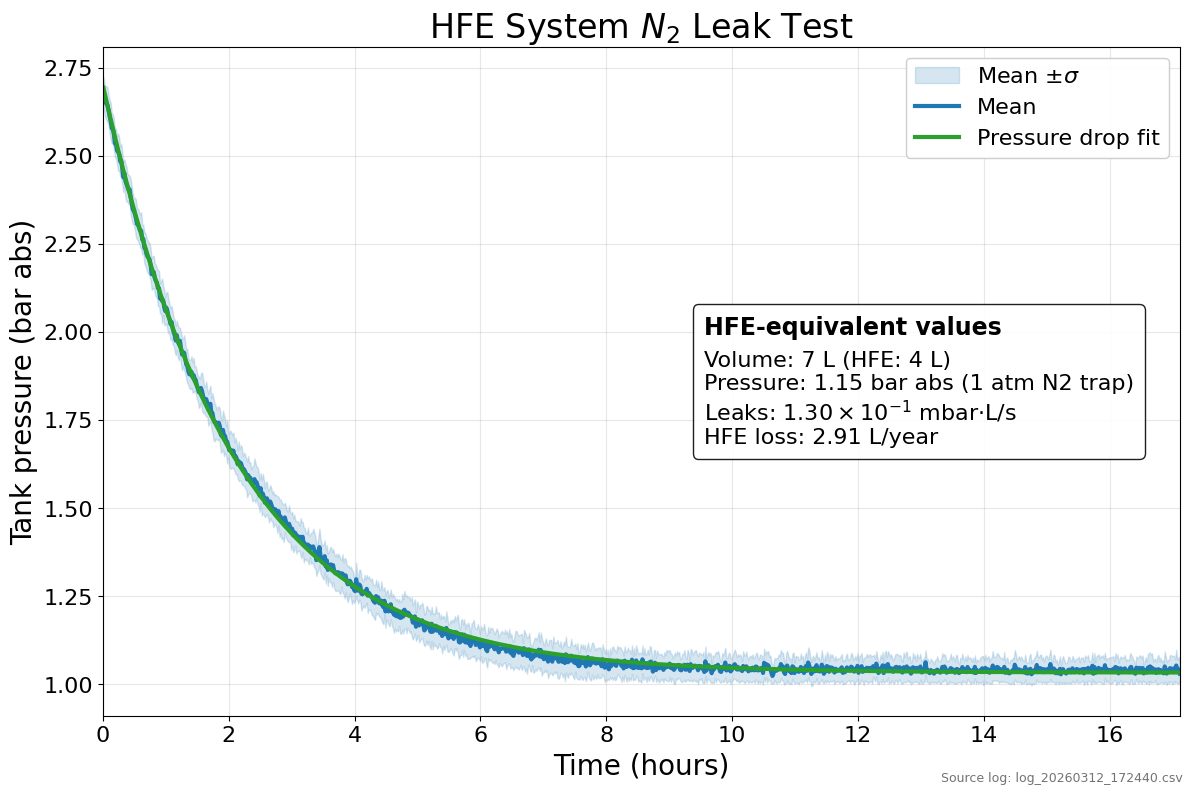

In [24]:
for result in system_results:
    fig, _ = leak_tools.plot_system_pressure_result(result)
    display(fig)
    plt.close(fig)


## 2. Vacuum pressure-rise checks

Next step: fold in the workflow from `analysis/notebooks/vacuum_pressure_rise.ipynb`.

## 3. Reservoir leak checks

These are the legacy two-point reservoir tests. The same notebook now runs them through `orca.leaks`.

In [25]:
RESERVOIR_VOLUME_L = 11.0
RESERVOIR_OPERATING_GAUGE_BAR = leak_tools.HFE_VAPOR_GAUGE_BAR
PSI_TO_BAR = 0.0689476

reservoir_cases = [
    leak_tools.ReservoirLeakCase(
        label='FEP O-ring',
        slug='fep',
        time_h=np.array([0.0, 19.0 + 2.0 / 60.0], dtype=float),
        pressure_abs_bar=np.array(
            [
                23.0 * PSI_TO_BAR + leak_tools.P_ATM_BAR,
                10.0 * PSI_TO_BAR + leak_tools.P_ATM_BAR,
            ],
            dtype=float,
        ),
        volume_l=RESERVOIR_VOLUME_L,
        operating_gauge_bar=RESERVOIR_OPERATING_GAUGE_BAR,
        x_max_h=leak_tools.DEFAULT_RESERVOIR_XMAX_H,
        y_max_bar=leak_tools.DEFAULT_RESERVOIR_YMAX_BAR,
        source_note='Legacy reservoir test data: FEP O-ring',
    ),
    leak_tools.ReservoirLeakCase(
        label='Viton O-ring',
        slug='viton',
        time_h=np.array([0.0, 4.0 + 47.0 / 60.0], dtype=float),
        pressure_abs_bar=np.array([1.65, 1.35], dtype=float),
        volume_l=RESERVOIR_VOLUME_L,
        operating_gauge_bar=RESERVOIR_OPERATING_GAUGE_BAR,
        x_max_h=leak_tools.DEFAULT_RESERVOIR_XMAX_H,
        y_max_bar=leak_tools.DEFAULT_RESERVOIR_YMAX_BAR,
        source_note='Legacy reservoir test data: Viton O-ring',
    ),
]

reservoir_results = [leak_tools.analyze_reservoir_case(case) for case in reservoir_cases]
reservoir_summary = leak_tools.reservoir_summary_table(reservoir_results)
display(
    reservoir_summary.round(
        {
            'elapsed_h': 3,
            'fit_k_per_h': 5,
            'start_pressure_bar_abs': 3,
            'end_pressure_bar_abs': 3,
            'volume_l': 1,
            'operating_pressure_bar_abs': 3,
            'start_decay_mbar_h': 1,
            'leak_mbar_l_s': 4,
            'hfe_loss_l_year': 2,
        }
    )
)


,case,elapsed_h,fit_k_per_h,start_pressure_bar_abs,end_pressure_bar_abs,volume_l,operating_pressure_bar_abs,start_decay_mbar_h,leak_mbar_l_s,hfe_loss_l_year
0,FEP O-ring,19.033,-0.04376,2.599,1.703,11.0,1.159,69.4,0.0194,0.43
1,Viton O-ring,4.783,-0.13318,1.650,1.350,11.0,1.159,84.8,0.0591,1.32


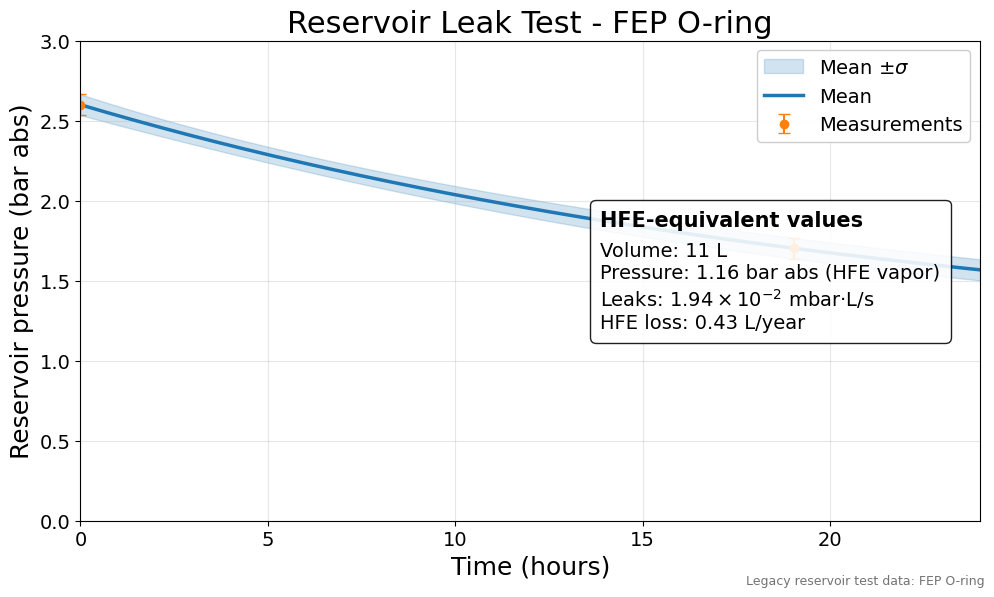

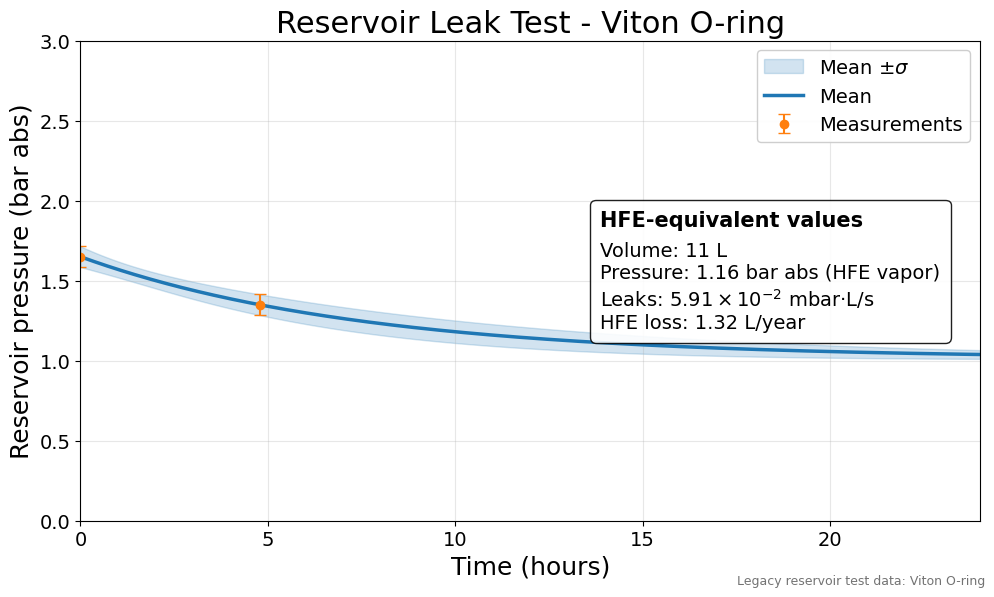

In [26]:
for result in reservoir_results:
    fig, _ = leak_tools.plot_reservoir_leak_result(result)
    display(fig)
    plt.close(fig)
